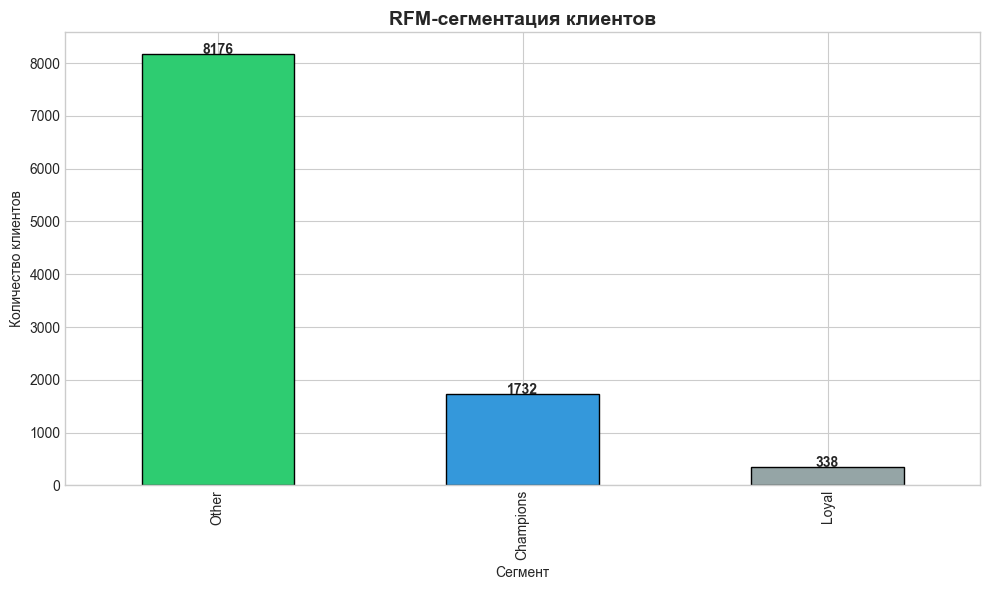

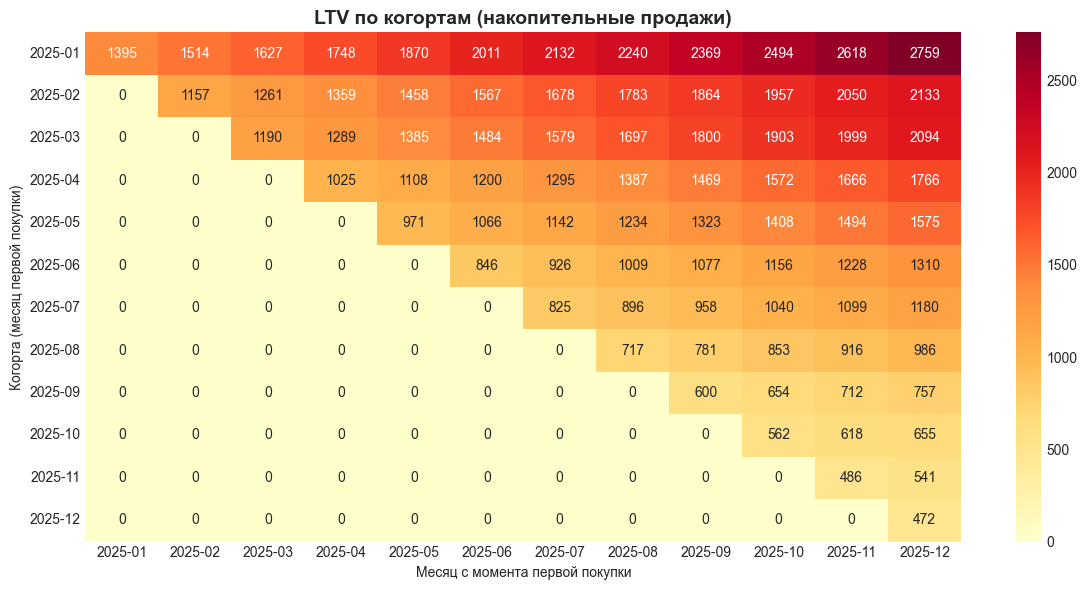

✅ RFM-анализ завершён, сохранены графики и CSV


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Загрузка данных (используем файлы из родительской папки)
transactions = pd.read_csv('../transactions.csv', sep=';', encoding='utf-8', decimal=',')
customers = pd.read_csv('../customers.csv', sep=';', encoding='utf-8', decimal=',')

# Фильтрация возвратов
transactions = transactions[transactions['is_returned'] == False]
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# RFM-метрики
snapshot_date = transactions['t_dat'].max() + timedelta(days=1)

rfm = transactions.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (snapshot_date - x.max()).days),
    Frequency=('t_dat', 'count'),
    Monetary=('price', 'sum')
)

# Сегментация
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

def segment(row):
    if row['RFM_score'] in ['444','443','434','344']: return 'Champions'
    elif row['RFM_score'] in ['442','441','432','431']: return 'Loyal'
    else: return 'Other'

rfm['Segment'] = rfm.apply(segment, axis=1)

# Визуализация сегментов
fig, ax = plt.subplots(figsize=(10,6))
segment_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71', '#3498db', '#95a5a6']
segment_counts.plot(kind='bar', color=colors, edgecolor='black')
ax.set_title('RFM-сегментация клиентов', fontsize=14, fontweight='bold')
ax.set_xlabel('Сегмент')
ax.set_ylabel('Количество клиентов')
for i, v in enumerate(segment_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

# LTV по когортам (по месяцам первой покупки)
transactions['month'] = transactions['t_dat'].dt.to_period('M')
cohort_data = transactions.groupby(['customer_id', 'month']).size().reset_index(name='orders')
first_purchase = transactions.groupby('customer_id')['t_dat'].min().dt.to_period('M')
cohort_data['cohort'] = cohort_data['customer_id'].map(first_purchase)
cohort_counts = cohort_data.groupby(['cohort', 'month']).size().unstack(fill_value=0)
ltv_cohort = cohort_counts.cumsum(axis=1)

plt.figure(figsize=(12,6))
sns.heatmap(ltv_cohort, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('LTV по когортам (накопительные продажи)', fontsize=14, fontweight='bold')
plt.xlabel('Месяц с момента первой покупки')
plt.ylabel('Когорта (месяц первой покупки)')
plt.tight_layout()
plt.savefig('ltv_cohorts.png', dpi=150, bbox_inches='tight')
plt.show()

# Сохраняем RFM-таблицу
rfm.to_csv('rfm_segmentation.csv', encoding='utf-8-sig', sep=';', decimal=',')
print("✅ RFM-анализ завершён, сохранены графики и CSV")